In [1]:
import numpy as np
import random
from scipy.spatial.transform import Rotation as R
import ast
import re
import matplotlib.pyplot as plt

Let's start by unpacking and graphing the signal events. We can worry about the rest from there.

In [2]:
with open('cleanEjectionRuns.txt', 'r', encoding='utf-8') as file:
    dictList = []
    for line in file:
        line = re.sub(r"np\.float64\((.*?)\)", r"\1", line)
        line = re.sub(r"array\((.*?)\)", r"\1", line)
        dictList.append(ast.literal_eval(line))

In [3]:
print(dictList[0])

{'p9DeltaE': 2.098902120774117, 'Exostar mass': [3.1599143e+29], 'Exostar Velocity': [20336.03360336], 'Nearest Approach to Sun': 904.8496454256012, 'Nearest Approach to Planet 9': 10.250357790768977, 'Planet 9 Data': [5.202646295843797, 693.6988974877999, 0.7453955531087342, 0.5063036666963058, 2.3882501434486647, 5.283494729323527], 'Flyby Angle': 50.31191041657988, 'P9 Dist to Sun During Flyby': 1165.0611490533624}


Alright, that gives us all of the dictionaries. Let's make a function to extract all of the data for each file.

In [4]:
def unpackFile(filenName):
    #First we open the file and extract the lists
    with open(str(filenName), 'r', encoding='utf-8') as file:
        dictList = []
        for line in file:
            line = re.sub(r"np\.float64\((.*?)\)", r"\1", line)
            line = re.sub(r"array\((.*?)\)", r"\1", line)
            dictList.append(ast.literal_eval(line))

    #Now we extract the values using list comprehension
    deltaEList = [item["p9DeltaE"] for item in dictList]
    massList = [item["Exostar mass"][0] for item in dictList]
    vList = [item["Exostar Velocity"][0] for item in dictList]
    sunApproachList = [item["Nearest Approach to Sun"] for item in dictList]
    p9ApproachList = [item["Nearest Approach to Planet 9"] for item in dictList]
    angleList = [item["Flyby Angle"] for item in dictList]
    p9DistToSunList = [item["P9 Dist to Sun During Flyby"] for item in dictList]
    
    #Now unpack Planet 9 parameters specifically
    p9DataList = [item["Planet 9 Data"] for item in dictList]
    p9MassList = [item[0] for item in p9DataList]
    p9AList = [item[1] for item in p9DataList]
    p9EList = [item[2] for item in p9DataList]
    p9IList = [item[3] for item in p9DataList]
    p9omegaList = [item[4] for item in p9DataList]
    p9ThetaList = [item[5] for item in p9DataList]
    
    return {"EList": deltaEList, 
            "MassList": massList, 
            "vList": vList, 
            "sunApproachList": sunApproachList, 
            "p9ApproachList": p9ApproachList, 
            "angleList": angleList, 
            "p9DistToSunList": p9DistToSunList, 
            "p9MassList": p9MassList, 
            "p9AList": p9AList, 
            "p9EList": p9EList, 
            "p9IList": p9IList, 
            "p9omegaList": p9omegaList, 
            "p9ThetaList": p9ThetaList
           }

In [5]:
cleanEjectDict = unpackFile('cleanEjectionRuns.txt')

Seems to have worked. Great! Time to do this for all of the files!

In [8]:
noActivityDict = unpackFile('noActivityRuns.txt')
offResonanceDict = unpackFile('offResonanceRuns.txt')
perturbedDict = unpackFile('perturbedRuns.txt')

In [9]:
print(type(cleanEjectDict))

<class 'dict'>


In [10]:
print(len(cleanEjectDict["EList"]))
print(len(noActivityDict["EList"]))
print(len(offResonanceDict["EList"]))
print(len(perturbedDict["EList"]))
print("Total Runs:", (len(cleanEjectDict["EList"]) + len(noActivityDict["EList"]) + len(offResonanceDict["EList"]) + len(perturbedDict["EList"])))

850
958038
25669
40428
Total Runs: 1024985


In [11]:
def quadPlot(xAxis, numRuns, var, CleanDict = cleanEjectDict, PerturbedDict = perturbedDict, OffResonanceDict = offResonanceDict, NoActivityDict = noActivityDict):
    fig, axs = plt.subplots(2, 2, figsize=(8, 6))
    
    axs[0,0].hist(CleanDict[str(var)])
    axs[0,0].set_xlabel(str(xAxis))
    axs[0,0].set_ylabel(f"Events Per {numRuns} Runs")
    axs[0,0].set_title("Clean Ejections")

    axs[1,0].hist(PerturbedDict[str(var)])
    axs[1,0].set_xlabel(str(xAxis))
    axs[1,0].set_ylabel(f"Events Per {numRuns} Runs")
    axs[1,0].set_title("Known Planets Perturbed")

    axs[0,1].hist(OffResonanceDict[str(var)])
    axs[0,1].set_xlabel(str(xAxis))
    axs[0,1].set_ylabel(f"Events Per {numRuns} Runs")
    axs[0,1].set_title("Pluto-Neptune Resonance Disrupted")

    axs[1,1].hist(NoActivityDict[str(var)])
    axs[1,1].set_xlabel(str(xAxis))
    axs[1,1].set_ylabel(f"Events Per {numRuns} Runs")
    axs[1,1].set_title("No Significant Impact")

    plt.tight_layout()

    plt.show()
    return fig, axs

In [12]:
#Flyby Angle
ejectList = []

list1 = perturbedDict["EList"]
list2 = offResonanceDict["EList"]
list3 = noActivityDict["EList"]


for x in range(len(perturbedDict["EList"])):
    if perturbedDict["EList"][x] > 1:
        ejectList.append(perturbedDict["angleList"][x])

for x in range(len(offResonanceDict["EList"])):
    if offResonanceDict["EList"][x] > 1:
        ejectList.append(offResonanceDict["angleList"][x])

for x in range(len(noActivityDict["EList"])):
    if noActivityDict["EList"][x] > 1:
        ejectList.append(noActivityDict["angleList"][x])

fullEjections = ejectList + cleanEjectDict["angleList"]

fullPopList = perturbedDict["angleList"] + offResonanceDict["angleList"] + noActivityDict["angleList"] + cleanEjectDict["angleList"]

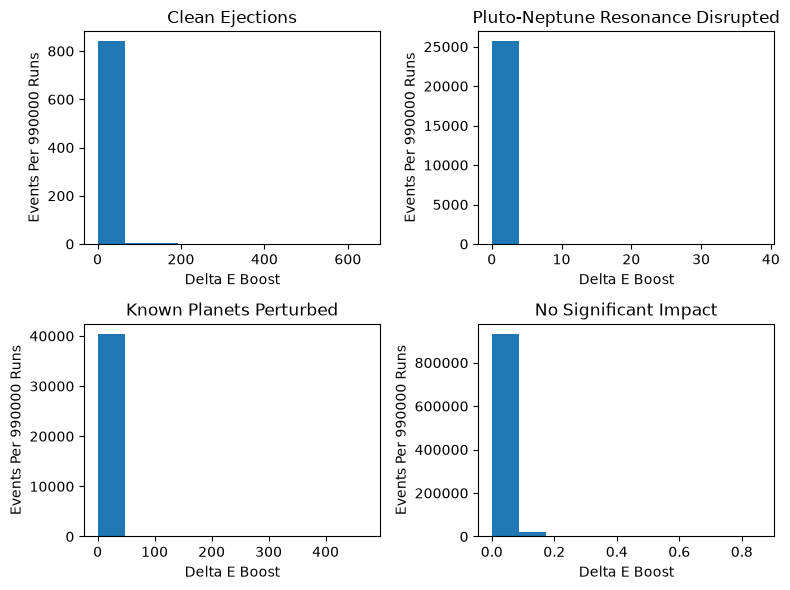

In [13]:
#Delta E Boosts
fig, axs = quadPlot("Delta E Boost", 990000, "EList")

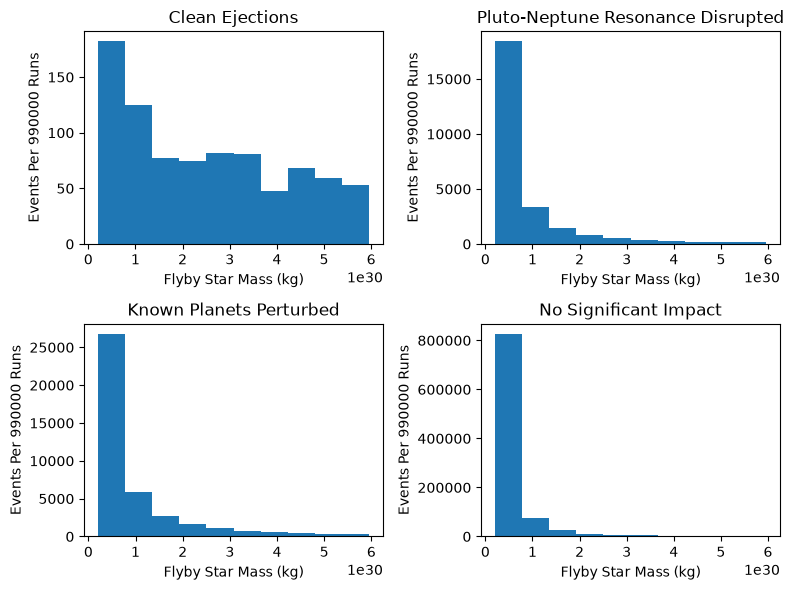

In [14]:
#Flyby Star Mass
fig, axs = quadPlot("Flyby Star Mass (kg)", 990000, "MassList")

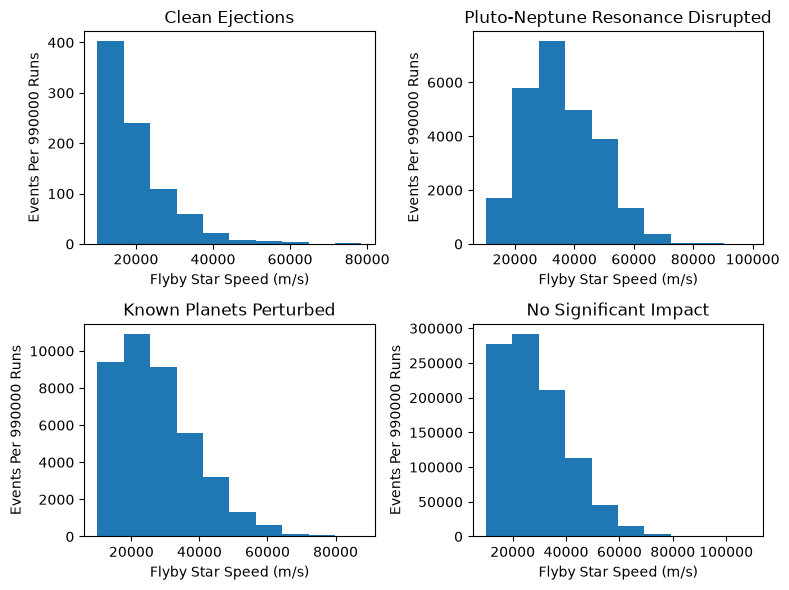

In [15]:
#Flyby Star Speed Plots
fig, axs = quadPlot("Flyby Star Speed (m/s)", 990000, "vList")

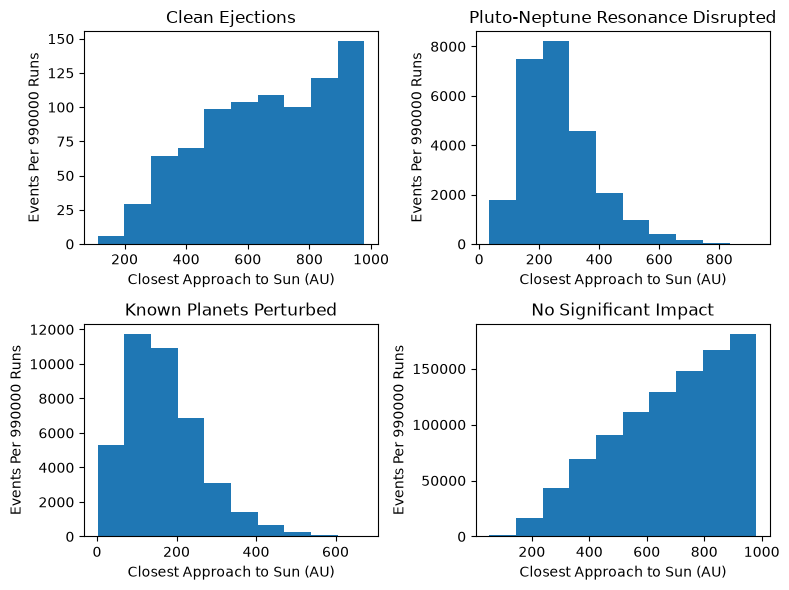

In [16]:
#Closest Approach to Sun
fig, axs = quadPlot("Closest Approach to Sun (AU)", 990000, "sunApproachList")

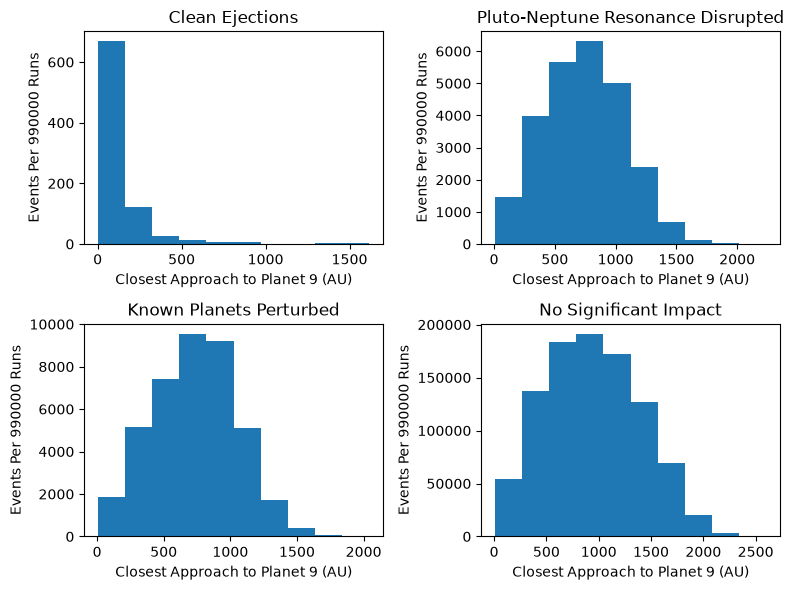

In [17]:
#Closest Approach to Planet 9
fig, axs = quadPlot("Closest Approach to Planet 9 (AU)", 990000, "p9ApproachList")

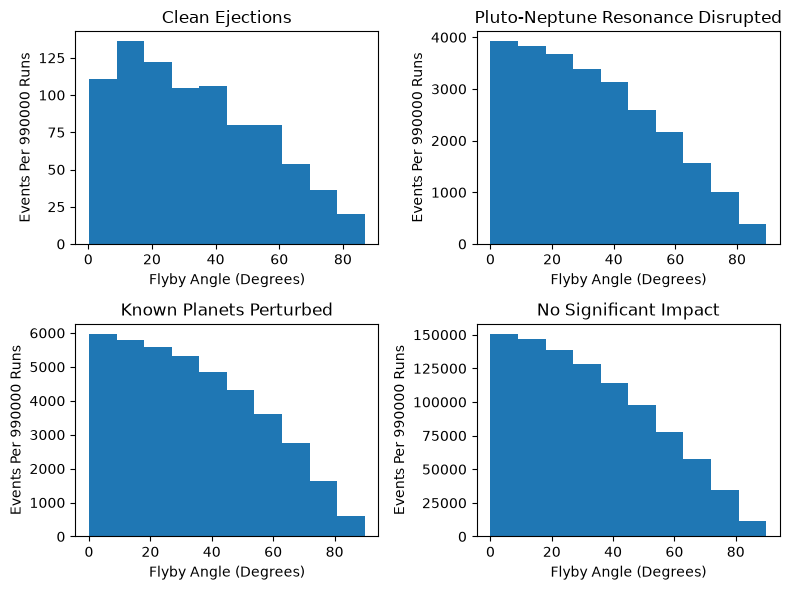

In [36]:
#Flyby Angle
fig, axs = quadPlot("Flyby Angle (Degrees)", 990000, "angleList")

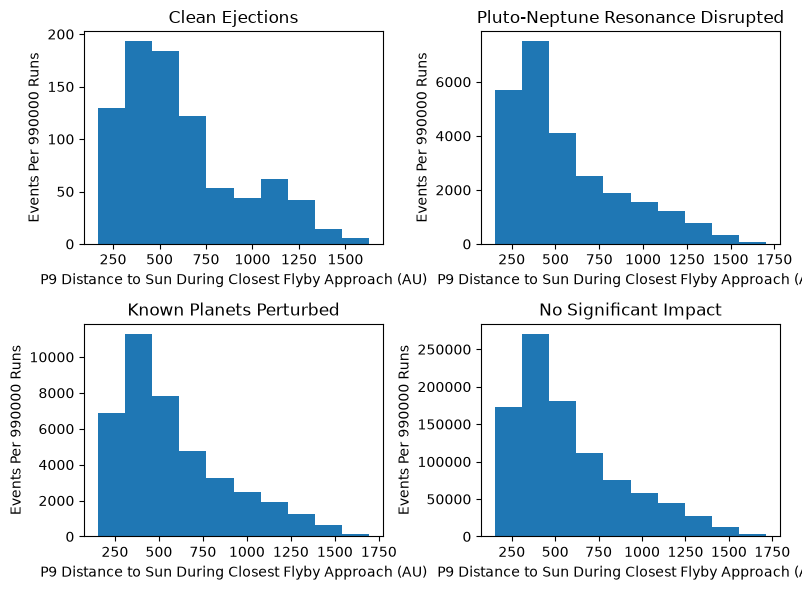

In [19]:
#P9 Dist to Sun During Flyby
fig, axs = quadPlot("P9 Distance to Sun During Closest Flyby Approach (AU)", 990000, "p9DistToSunList")

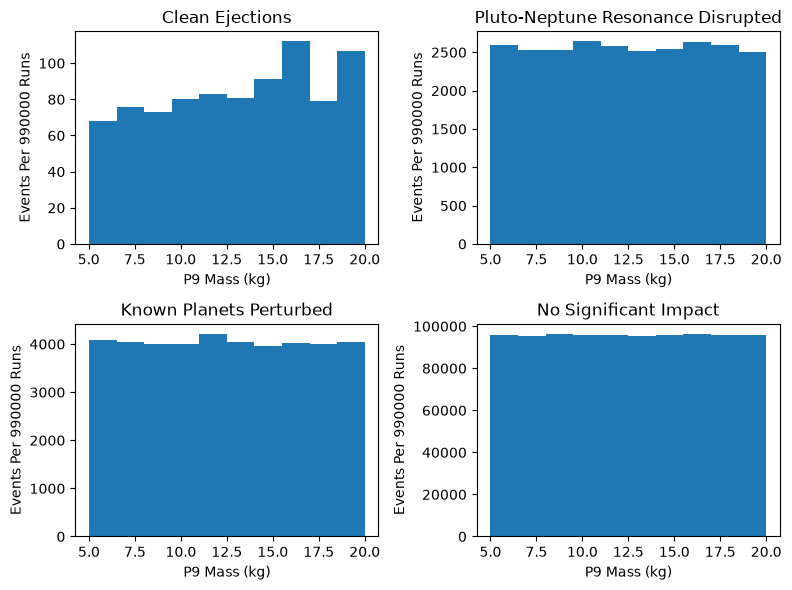

In [20]:
#P9 Mass
fig, axs = quadPlot("P9 Mass (kg)", 990000, "p9MassList")

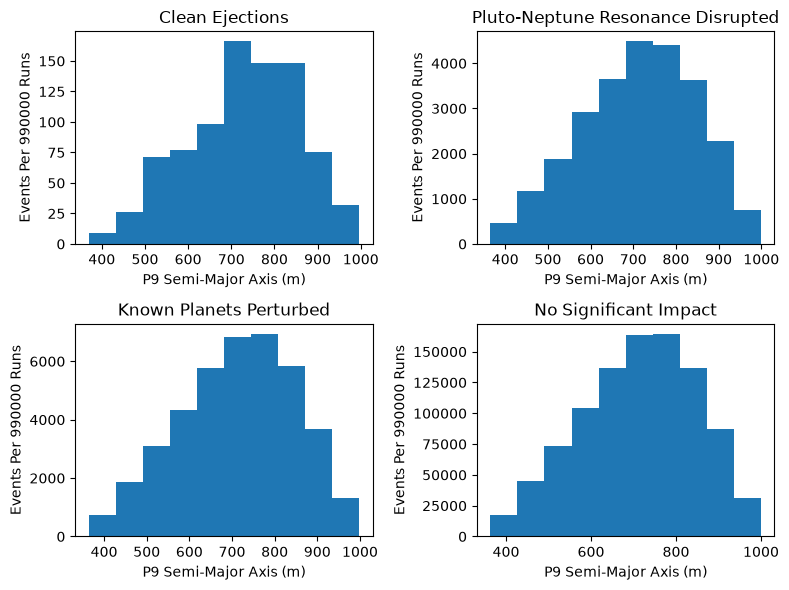

In [21]:
#P9 Semi-Major Axis
fig, axs = quadPlot("P9 Semi-Major Axis (m)", 990000, "p9AList")

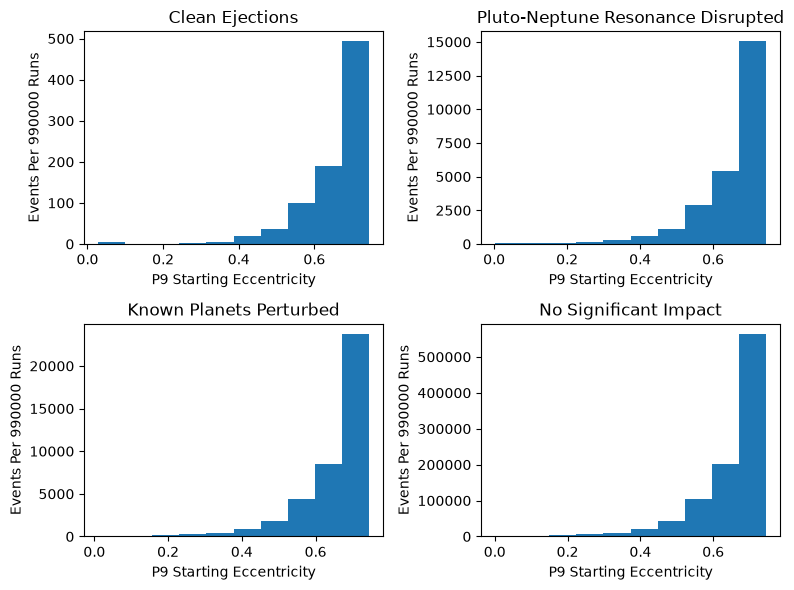

In [22]:
#P9 Eccentricity 
fig, axs = quadPlot("P9 Starting Eccentricity", 990000, "p9EList")

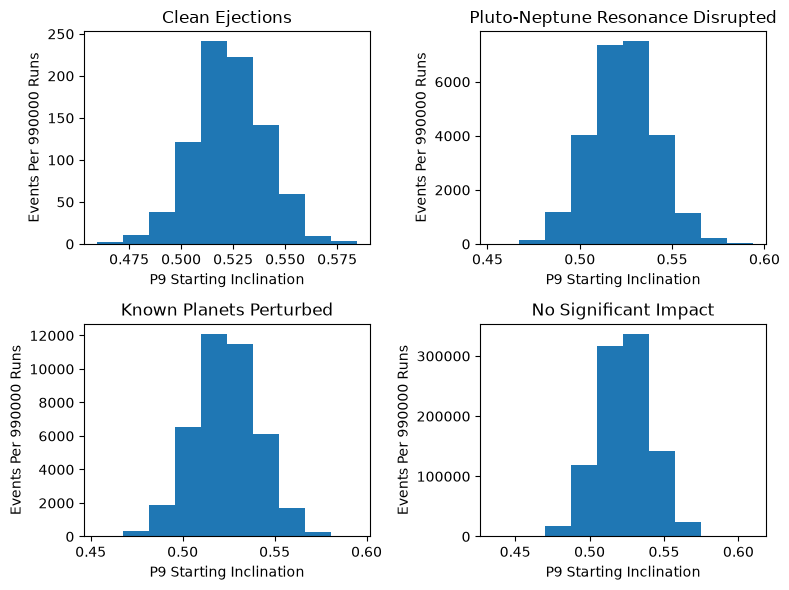

In [23]:
#P9 Inclination 
fig, axs = quadPlot("P9 Starting Inclination", 990000, "p9IList")

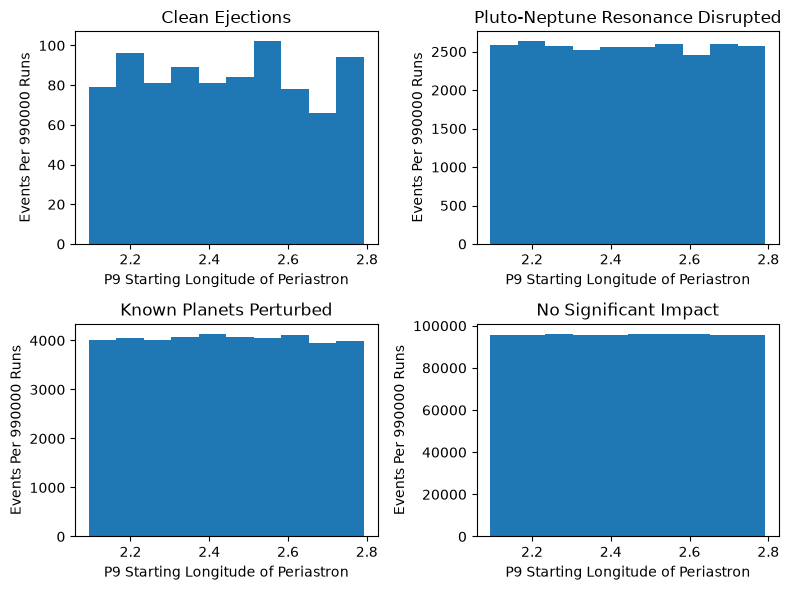

In [24]:
#P9 pomega 
fig, axs = quadPlot("P9 Starting Longitude of Periastron", 990000, "p9omegaList")

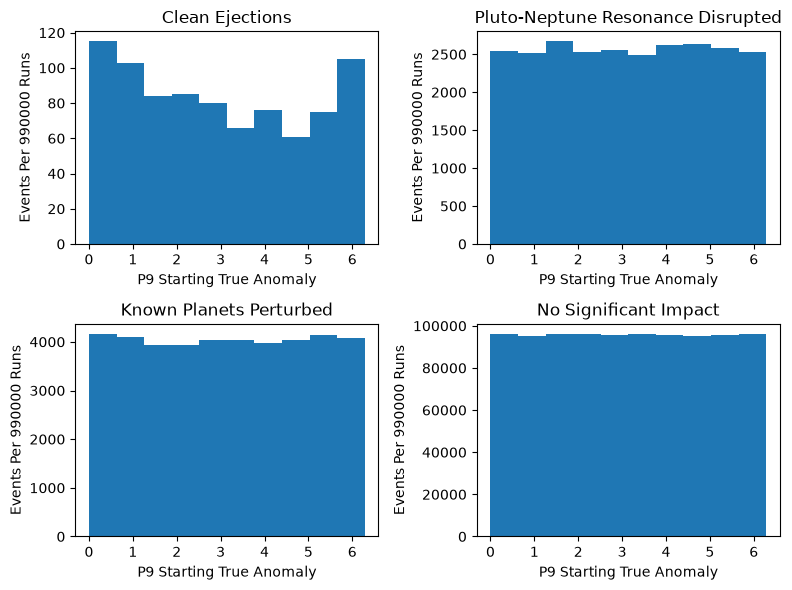

In [25]:
#P9 Theta
fig, axs = quadPlot("P9 Starting True Anomaly", 990000, "p9ThetaList")

In [26]:
def planet9SurvivalRate(dist):
    closeSurvivals = 0
    closeEjections = 0
    
    for x in range(len(perturbedP9ApproachList)):
        if perturbedP9ApproachList[x] < dist:
            if perturbedEList[x] < 1:
                closeSurvivals += 1
            else:
                closeEjections += 1

    for d in offResonanceP9ApproachList:
        if d < dist:
            if perturbedEList[x] < 1:
                closeSurvivals += 1
            else:
                closeEjections += 1

    for d in noActivityP9ApproachList:
        if d < dist:
            closeSurvivals += 1
    
    for d in cleanEjectP9ApproachList:
        if d < dist:
            closeEjections += 1
            
    print(f"Planet 9 has {closeEjections} ejections and {closeSurvivals} survivals at a distance of {dist} AU, giving it a survival rate of {closeSurvivals/(closeSurvivals + closeEjections)}") 
    
    return closeEjections, closeSurvivals

In [27]:
def planet9PerturbationRate(dist, verbose = True):
    closeSurvivals = 0
    closePerturbations = 0
    
    for x in range(len(perturbedSunApproachList)):
        if perturbedP9ApproachList[x] < dist:
            if perturbedEList[x] < 0.05:
                closeSurvivals += 1
            else:
                closePerturbations += 1

    for d in offResonanceSunApproachList:
        if d < dist:
            if perturbedEList[x] < 0.05:
                closeSurvivals += 1
            else:
                closePerturbations += 1

    for d in noActivitySunApproachList:
        if d < dist:
            if noActivityEList[x] < 0.05:
                closeSurvivals += 1
            else:
                closePerturbations += 1
    
    for d in cleanEjectSunApproachList:
        if d < dist:
            closePerturbations += 1
            
    if verbose == True:
        print(f"Planet 9 has {closePerturbations} perturbations and {closeSurvivals} survivals at a distance of {dist} AU to the sun, giving it a survival rate of {closeSurvivals/(closeSurvivals + closePerturbations)}") 
    
        return closePerturbations, closeSurvivals

    else:
        return closePerturbations/(closeSurvivals + closePerturbations)

In [28]:
type(cleanEjectDict["p9ThetaList"])

list

In [29]:
ejectList = []

list1 = perturbedDict["EList"]
list2 = offResonanceDict["EList"]
list3 = noActivityDict["EList"]


for x in range(len(perturbedDict["EList"])):
    if perturbedDict["EList"][x] > 1:
        ejectList.append(perturbedDict["p9ThetaList"][x])

for x in range(len(offResonanceDict["EList"])):
    if offResonanceDict["EList"][x] > 1:
        ejectList.append(offResonanceDict["p9ThetaList"][x])

for x in range(len(noActivityDict["EList"])):
    if noActivityDict["EList"][x] > 1:
        ejectList.append(noActivityDict["p9ThetaList"][x])

fullEjections = ejectList + cleanEjectDict["p9ThetaList"]

Text(0.5, 1.0, 'True Longitude for All Ejections')

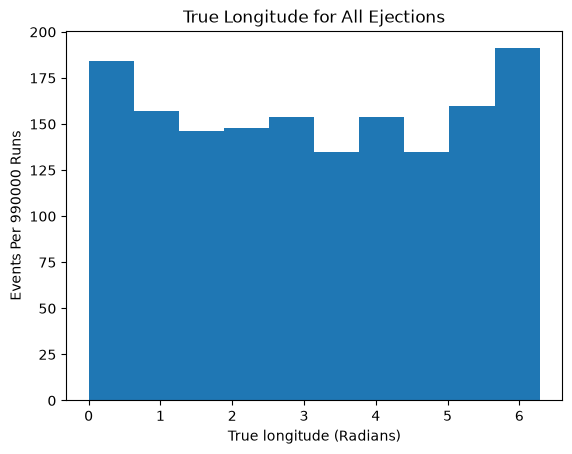

In [30]:
plt.hist(fullEjections)
plt.xlabel("True longitude (Radians)")
plt.ylabel(f"Events Per {990000} Runs")
plt.title("True Longitude for All Ejections")

In [31]:
fullPopList = perturbedDict["p9ThetaList"] + cleanEjectDict["p9ThetaList"] + offResonanceDict["p9ThetaList"] + noActivityDict["p9ThetaList"]

Text(0.5, 1.0, 'True Longitude for All Runs')

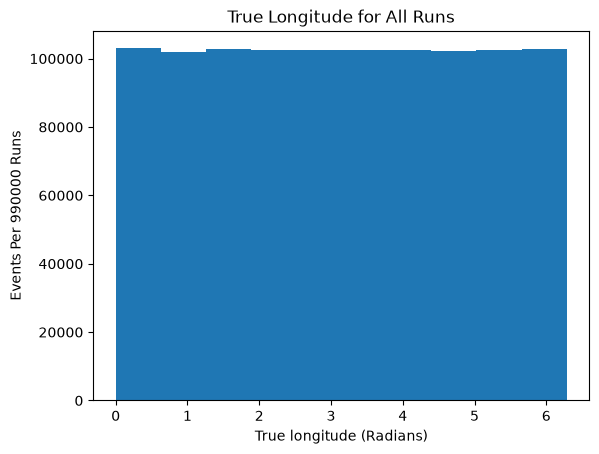

In [37]:
plt.hist(fullPopList)
plt.xlabel("True longitude (Radians)")
plt.ylabel(f"Events Per {990000} Runs")
plt.title("True Longitude for All Runs")

In [33]:
def planet9SurvivalRate(dist):
    closeSurvivals = 0
    closeEjections = 0
    
    for x in range(len(perturbedP9ApproachList)):
        if perturbedP9ApproachList[x] < dist:
            if perturbedEList[x] < 1:
                closeSurvivals += 1
            else:
                closeEjections += 1

    for d in offResonanceP9ApproachList:
        if d < dist:
            if perturbedEList[x] < 1:
                closeSurvivals += 1
            else:
                closeEjections += 1

    for d in noActivityP9ApproachList:
        if d < dist:
            closeSurvivals += 1
    
    for d in cleanEjectP9ApproachList:
        if d < dist:
            closeEjections += 1
            
    print(f"Planet 9 has {closeEjections} ejections and {closeSurvivals} survivals at a distance of {dist} AU, giving it a survival rate of {closeSurvivals/(closeSurvivals + closeEjections)}") 
    
    return closeEjections, closeSurvivals

In [34]:
distList = np.linspace(5, 600, 120)
graphingDists = np.linspace(2.5, 597.5, 120)

ejectList = []

for x in range(len(perturbedDict["EList"])):
    if perturbedDict["EList"][x] > 1:
        ejectList.append(perturbedDict["p9ApproachList"][x])

for x in range(len(offResonanceDict["EList"])):
    if offResonanceDict["EList"][x] > 1:
        ejectList.append(offResonanceDict["p9ApproachList"][x])

for x in range(len(noActivityDict["EList"])):
    if noActivityDict["EList"][x] > 1:
        ejectList.append(noActivityDict["p9ApproachList"][x])

fullEjectionsDists = ejectList + cleanEjectDict["p9ApproachList"]

fullPopDists = perturbedDict["p9ApproachList"] + offResonanceDict["p9ApproachList"] + noActivityDict["p9ApproachList"] +  cleanEjectDict["p9ApproachList"]

survivalRates = []

#Iterate over all distances
for x in range(len(distList)):
    print(f"SCANNING DIST: {distList[x]}")
    
    ejectedNo = 0
    totalNo = 0

    #Find all events within this bin that survived and/or didn't
    for ejectedDist in fullEjectionsDists:
        if ejectedDist < distList[x] and ejectedDist > distList[x-1]:
            ejectedNo += 1

    for fullPopDist in fullPopDists:
        if fullPopDist < distList[x] and fullPopDist > distList[x-1]:
            totalNo += 1

    #Now calculate the survival rate and track it
    if totalNo > 0:
        survivalRates.append(ejectedNo/totalNo * 100)    

    else:
        survivalRates.append(-1)

SCANNING DIST: 5.0
SCANNING DIST: 10.0
SCANNING DIST: 15.0
SCANNING DIST: 20.0
SCANNING DIST: 25.0
SCANNING DIST: 30.0
SCANNING DIST: 35.0
SCANNING DIST: 40.0
SCANNING DIST: 45.0
SCANNING DIST: 50.0
SCANNING DIST: 55.0
SCANNING DIST: 60.0
SCANNING DIST: 65.0
SCANNING DIST: 70.0
SCANNING DIST: 75.0
SCANNING DIST: 80.0
SCANNING DIST: 85.0
SCANNING DIST: 90.0
SCANNING DIST: 95.0
SCANNING DIST: 100.0
SCANNING DIST: 105.0
SCANNING DIST: 110.0
SCANNING DIST: 115.0
SCANNING DIST: 120.0
SCANNING DIST: 125.0
SCANNING DIST: 130.0
SCANNING DIST: 135.0
SCANNING DIST: 140.0
SCANNING DIST: 145.0
SCANNING DIST: 150.0
SCANNING DIST: 155.0
SCANNING DIST: 160.0
SCANNING DIST: 165.0
SCANNING DIST: 170.0
SCANNING DIST: 175.0
SCANNING DIST: 180.0
SCANNING DIST: 185.0
SCANNING DIST: 190.0
SCANNING DIST: 195.0
SCANNING DIST: 200.0
SCANNING DIST: 205.0
SCANNING DIST: 210.0
SCANNING DIST: 215.0
SCANNING DIST: 220.0
SCANNING DIST: 225.0
SCANNING DIST: 230.0
SCANNING DIST: 235.0
SCANNING DIST: 240.0
SCANNING DIS

In [35]:
nullDists = []
for x in range(len(survivalRates)):
    if survivalRates[x] == -1:
        nullDists.append(graphingDists[x])

print(nullVals)

ejectionDists = [item for item in graphingDists if item not in nullDists]
ejectionRates = [item/100 for item in survivalRates if item not in [-1]]
print(len(ejectionDists), len(ejectionRates))

NameError: name 'nullVals' is not defined

In [ ]:
plt.scatter(ejectionDists, ejectionRates)
#plt.yscale("log")
plt.ylabel("Ejection Rate")
plt.xlabel("Closest Flyby Distance to Planet 9 (AU)")
plt.title("Planet 9 Ejection Rate by Distance")